In [1]:
import os
os.chdir(r'C:\Users\Admin\Desktop\CUSTOMER COMPLAINT CLASSIFICATION')
print(os.getcwd())

C:\Users\Admin\Desktop\CUSTOMER COMPLAINT CLASSIFICATION


Test set weighted F1: 0.8971
                                                    precision    recall  f1-score   support

                       Checking or savings account       0.86      0.93      0.89     15063
Money transfer, virtual currency, or money service       0.88      0.78      0.83      8751
                                          Mortgage       0.96      0.95      0.95      5485
                                      Student loan       0.98      0.95      0.96      3684
                             Vehicle loan or lease       0.93      0.92      0.92      3802

                                          accuracy                           0.90     36785
                                         macro avg       0.92      0.91      0.91     36785
                                      weighted avg       0.90      0.90      0.90     36785



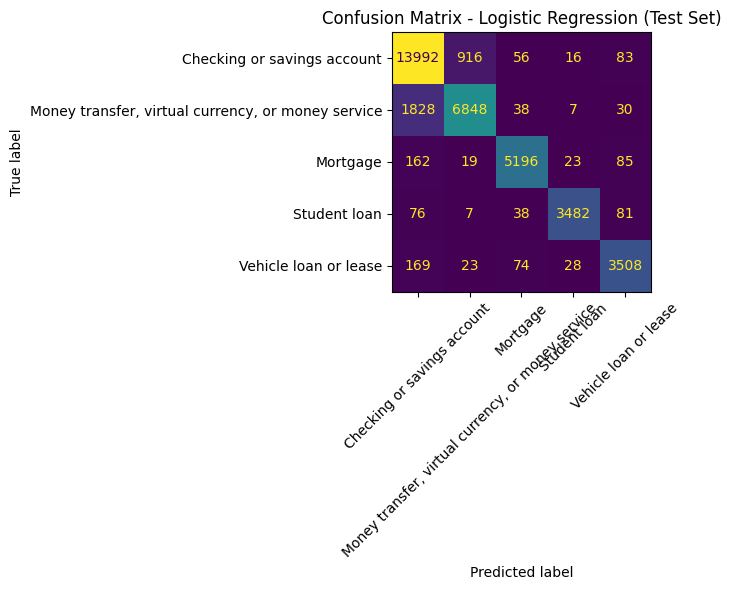

saved successfully


In [2]:
import pandas as pd
import joblib
import json
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Load test set
X_test = pd.read_csv('data/processed/X_test.csv').squeeze()
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

# Load champion model
model = joblib.load('models/latest/model.pkl')

# Predict on test set
y_pred = model.predict(X_test)

# Metrics
f1 = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred)

print('Test set weighted F1:', round(f1, 4))
print(report)

# Save eval predictions
pd.DataFrame({
    'text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': y_pred
}).to_csv('data/processed/eval_predictions.csv', index=False)

# Save metrics
with open('models/latest/metrics.json', 'w') as f:
    json.dump({'weighted_f1_test': round(f1, 4)}, f, indent=2)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Logistic Regression (Test Set)')
plt.tight_layout()
plt.savefig('models/latest/confusion_matrix.png', dpi=150)
plt.show()
print('saved successfully')